# Part 1 — Cooling-unit failures: a finite random variable

> Let $X$ be the number of cooling units that fail during a weekly maintenance window. The
> engineering model is

| $x$ | 0 | 1 | 2 | 3 | 4 |
|---|---|---|---|---|---|
| $P(X = x)$ | 0.58 | 0.26 | 0.10 | 0.04 | 0.02 |

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## a)

> Verify that the table is a valid PMF, state the support, and distinguish the random variable $X$
> from an observed value $x$.


$$0 \le p_X(x) \le 1 \quad \text{for every } x, \qquad \sum_x p_X(x) = 1$$

In [2]:
x = np.array([0, 1, 2, 3, 4])
pmf = np.array([0.58, 0.26, 0.10, 0.04, 0.02])

print("Every p_X(x) between 0 and 1:", np.all((pmf >= 0) & (pmf <= 1)))
print("Sum of all p_X(x):", pmf.sum())

Every p_X(x) between 0 and 1: True
Sum of all p_X(x): 1.0


**Valid PMF:** every probability lies between 0 and 1, and together they add to exactly 1, so the
table is a valid PMF.

**Support:** the set of values $X$ can take with positive probability,

$$\text{supp}(X) = \{0, 1, 2, 3, 4\}$$

**$X$ versus $x$:** $X$ is the random variable: the number of cooling units that will fail in a
coming week. Before the week it is unknown and could be anything from 0 to 4. $x$ is an observed
value: the number that actually failed once the week is over, for example $x = 1$. $X$ is
uncertain, while $x$ is a fixed number.

## b)

> Construct a table containing $x$, $p_X(x)$, and $F_X(x)$. Use it to calculate $P(X = 2)$,
> $P(X \le 1)$, $P(X \ge 2)$, and $P(1 < X \le 3)$.

$$F_X(x) = P(X \le x) = \sum_{k \le x} p_X(k)$$

In [3]:
cdf = np.cumsum(pmf)

table = pd.DataFrame({"x": x, "p_X(x)": pmf, "F_X(x)": cdf}).set_index("x")
table

,p_X(x),F_X(x)
x,,
0,0.58,0.58
1,0.26,0.84
2,0.10,0.94
3,0.04,0.98
4,0.02,1.00


$$P(X = 2) = p_X(2)$$

$$P(X \le 1) = F_X(1)$$

$$P(X \ge 2) = 1 - P(X \le 1) = 1 - F_X(1)$$

$$P(1 < X \le 3) = F_X(3) - F_X(1)$$

Because $X$ only takes whole numbers, "$X \ge 2$" is the complement of "$X \le 1$", and
"$1 < X \le 3$" means $X$ is 2 or 3.

In [4]:
# x runs from 0 to 4, so position i in each array holds the value for x = i.
print(f"P(X = 2)      = p_X(2)          = {pmf[2]:.2f}")
print(f"P(X <= 1)     = F_X(1)          = {cdf[1]:.2f}")
print(f"P(X >= 2)     = 1 - F_X(1)      = {1 - cdf[1]:.2f}")
print(f"P(1 < X <= 3) = F_X(3) - F_X(1) = {cdf[3] - cdf[1]:.2f}")

P(X = 2)      = p_X(2)          = 0.10
P(X <= 1)     = F_X(1)          = 0.84
P(X >= 2)     = 1 - F_X(1)      = 0.16
P(1 < X <= 3) = F_X(3) - F_X(1) = 0.14


**Interpretation:** most weeks (84 %) have at most one failure, and 16 % have two or more.

## c)

> Plot the PMF as a bar chart and the CDF as a step plot. Explain the meaning of the height at each
> value in both plots.

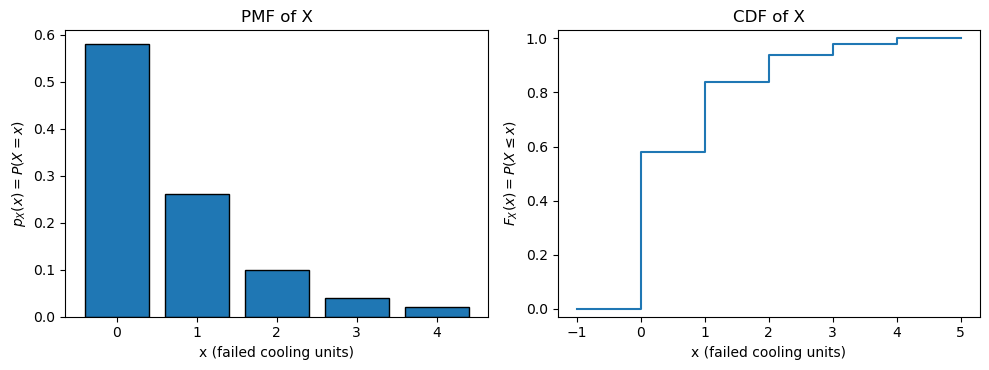

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))

ax[0].bar(x, pmf, edgecolor="black")
ax[0].set(title="PMF of X", xlabel="x (failed cooling units)", ylabel=r"$p_X(x) = P(X = x)$")

# Extend one step past each end: F is 0 before x = 0 and 1 after x = 4.
x_step = np.concatenate([[-1], x, [5]])
cdf_step = np.concatenate([[0], cdf, [1]])

ax[1].step(x_step, cdf_step, where="post")
ax[1].set(title="CDF of X", xlabel="x (failed cooling units)", ylabel=r"$F_X(x) = P(X \leq x)$",
          ylim=(-0.03, 1.03))

plt.tight_layout()
plt.show()

**PMF (left):** the height of the bar at $x$ is $p_X(x) = P(X = x)$, the probability that
**exactly** $x$ units fail in a week.

**CDF (right):** the height of the step at $x$ is $F_X(x) = P(X \le x)$, the probability that
**at most** $x$ units fail. Each jump in the CDF equals the height of the PMF bar at that value.

## d)

> Calculate and interpret $E[X]$, $\text{Var}(X)$, and $\text{SD}(X)$.

$$E[X] = \sum_x x \, p_X(x)$$

$$\text{Var}(X) = E[X^2] - (E[X])^2, \qquad E[X^2] = \sum_x x^2 \, p_X(x)$$

$$\text{SD}(X) = \sqrt{\text{Var}(X)}$$

In [6]:
mean = np.sum(x * pmf)
mean_sq = np.sum(x**2 * pmf)        # E[X^2]
variance = mean_sq - mean**2
sd = np.sqrt(variance)

print(f"E[X]   = {mean:.2f}")
print(f"E[X^2] = {mean_sq:.2f}")
print(f"Var(X) = {mean_sq:.2f} - {mean:.2f}^2 = {variance:.4f}")
print(f"SD(X)  = {sd:.4f}")

E[X]   = 0.66
E[X^2] = 1.34
Var(X) = 1.34 - 0.66^2 = 0.9044
SD(X)  = 0.9510


**$E[X] = 0.66$:** the long-run average number of failed units per week.

**$\text{Var}(X) = 0.9044$:** the average squared distance of $X$ from its mean, in failures², which
makes it hard to read directly.

**$\text{SD}(X) = 0.9510$:** the typical distance of the weekly count from its mean, in failed units.